> **This is a research notebook — one of seven, one per section of the paper.**
>
> For the presentation version, read the two self-contained notebooks in
> [`final/`](../final/) instead: [`1_information_bottleneck.ipynb`](../final/1_information_bottleneck.ipynb) (the whole argument, end to end) and [`2_transformer_extension.ipynb`](../final/2_transformer_extension.ipynb).
>
> This one is the deep dive on whether SGD's noise is the cause, and the gradient-SNR transition.

# 4 — Is compression caused by SGD noise?

**Reproduces:** paper section 4 — figures 5, 4C–D, and appendix I (figures I1, I2).

---

## The claim

Shwartz-Ziv & Tishby propose a *mechanism* for compression, built on the two phases of SGD:

* a **drift** phase, where the mean gradient across training examples is large relative to
  its standard deviation (high gradient SNR);
* a **diffusion** phase, where the mean falls below the standard deviation (low SNR).

Their argument runs: during diffusion the weights perform a constrained random walk, whose
stationary distribution is maximum-entropy subject to a training-error constraint;
maximising that entropy maximises $H(X\mid T)$; and since $H(X)$ is fixed,
$I(X;T) = H(X) - H(X\mid T)$ is therefore minimised. Compression, on this account, is
*driven by the randomness of SGD*.

## Two independent problems

**Theoretically**, the step from "the distribution of weights *across training runs* has
maximum entropy" to "the weights of *one particular run* maximise $H(X\mid T)$" does not
follow. $H(X\mid T)$ is uncertainty about inputs drawn from the data distribution, given a
*fixed* network. It is not uncertainty about which network you happened to train. These are
different random variables and there is no general reason the two coincide.

**Empirically**, the claim makes a prediction we can test directly: remove the randomness
and compression should disappear. Full-batch gradient descent uses the entire training set
for every update, so it has **no** sampling noise and **no** diffusion. If compression
survives, the mechanism is wrong.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "ibdl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from ibdl import plotting
plotting.use_paper_style()
FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

print("project root:", ROOT)

project root: /home/hooman/Desktop/InfoTheory/Project


In [2]:
from ibdl.cache import cached
from ibdl.data import load_tishby
from ibdl.experiments import TishbyConfig, LinearConfig, run_tishby, run_linear
from ibdl.planes import tishby_plane

_, _, full = load_tishby()
labels = full.y

cfgs = {
    ("tanh", "SGD"): TishbyConfig(activation="tanh", seed=0, track_grad_snr=True),
    ("relu", "SGD"): TishbyConfig(activation="relu", seed=0, track_grad_snr=True),
    ("tanh", "BGD"): TishbyConfig(activation="tanh", batch_size=None, lr=0.5,
                                  seed=0, track_grad_snr=True),
    ("relu", "BGD"): TishbyConfig(activation="relu", batch_size=None, lr=0.5,
                                  seed=0, track_grad_snr=True),
}
logs = {k: cached(c.tag, lambda c=c: run_tishby(c), verbose=False) for k, c in cfgs.items()}
planes = {k: tishby_plane(c, labels, estimator="binning") for k, c in cfgs.items()}

print(f"{'network':16s} {'updates/epoch':>14s} {'train acc':>10s} {'test acc':>9s}")
print("-" * 54)
for (act, opt), log in logs.items():
    ups = 1 if cfgs[(act, opt)].batch_size is None else int(np.ceil(3277 / 256))
    print(f"{act + ' / ' + opt:16s} {ups:>14d} {log.train_acc[-1]:>10.3f} {log.test_acc[-1]:>9.3f}")

network           updates/epoch  train acc  test acc
------------------------------------------------------
tanh / SGD                   13      0.981     0.962
relu / SGD                   13      0.987     0.973
tanh / BGD                    1      1.000     0.965
relu / BGD                    1      0.982     0.938


## 4.1 Figure 5 — compression survives the removal of stochasticity

Four networks: {tanh, ReLU} × {SGD, full-batch GD}. Batch gradient descent is completely
deterministic — same data, same update, every epoch.

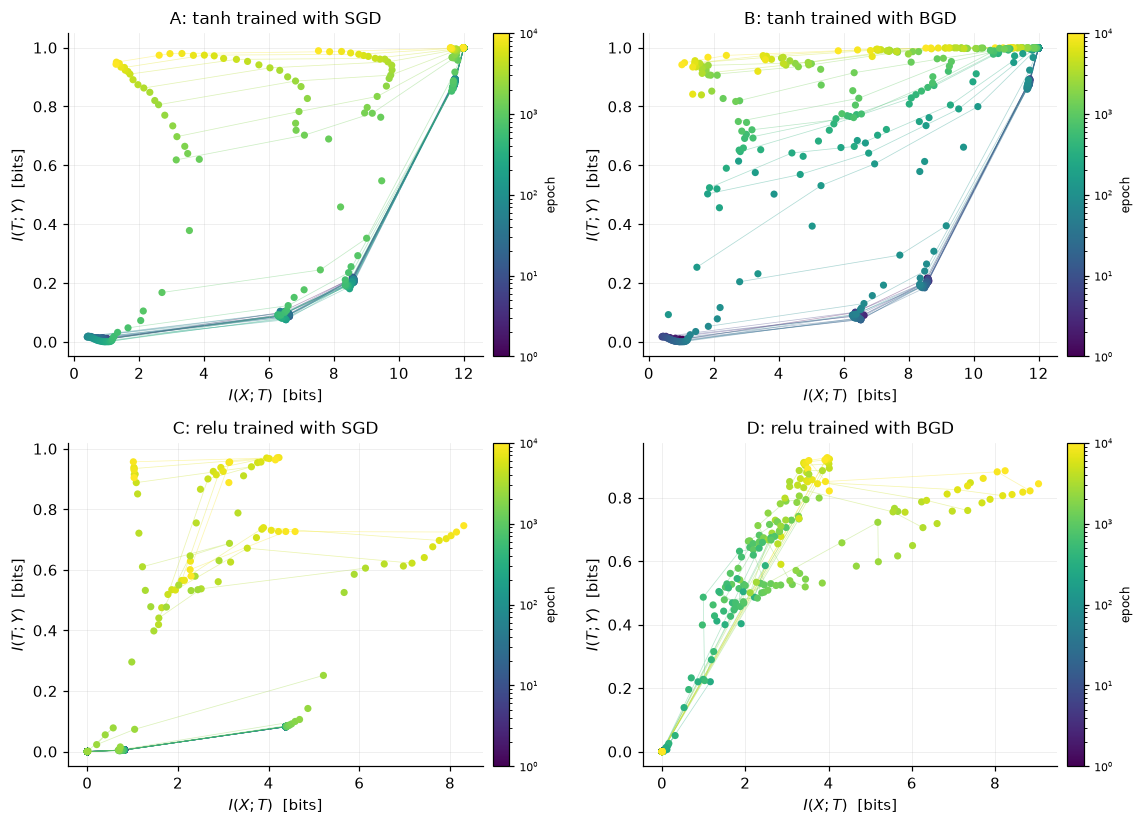

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10.6, 7.6))
order = [("tanh", "SGD"), ("tanh", "BGD"), ("relu", "SGD"), ("relu", "BGD")]
panel = ["A", "B", "C", "D"]
for ax, key, p in zip(axes.ravel(), order, panel):
    pl = planes[key]
    plotting.information_plane(pl.epochs, pl.I_XT, pl.I_TY, ax=ax,
                               title=f"{p}: {key[0]} trained with {key[1]}",
                               layer_names=pl.layer_names)
fig.tight_layout()
plotting.save(fig, "fig05_sgd_vs_bgd", FIGDIR)
plt.show()

In [4]:
print("compression per layer (bits lost from peak I(X;T))")
print(f"{'network':14s} " + " ".join(f"{n:>9s}" for n in planes[order[0]].layer_names)
      + f" {'TOTAL':>8s}")
print("-" * 82)
for key in order:
    c = planes[key].compression
    print(f"{key[0] + ' / ' + key[1]:14s} " + " ".join(f"{v:>9.2f}" for v in c)
          + f" {c.sum():>8.2f}")

print()
t_sgd, t_bgd = planes[("tanh", "SGD")].compression.sum(), planes[("tanh", "BGD")].compression.sum()
r_sgd, r_bgd = planes[("relu", "SGD")].compression.sum(), planes[("relu", "BGD")].compression.sum()
print(f"tanh: SGD {t_sgd:.2f} bits vs BGD {t_bgd:.2f} bits of compression")
print(f"ReLU: SGD {r_sgd:.2f} bits vs BGD {r_bgd:.2f} bits of compression")
print()
print("Removing ALL stochasticity from training leaves tanh compression essentially")
print("intact. The nonlinearity, not the noise, is what determines compression.")

compression per layer (bits lost from peak I(X;T))
network          L1 (10)    L2 (7)    L3 (5)    L4 (4)    L5 (3) L6 (2) out    TOTAL
----------------------------------------------------------------------------------
tanh / SGD          0.00      0.02      0.23      2.27      5.59      2.56    10.66
tanh / BGD          0.01      1.34      3.30      3.86      6.52      2.84    17.87
relu / SGD          0.00      0.00      0.00      0.02      0.08      0.37     0.47
relu / BGD          0.00      0.00      0.00      0.03      0.11      0.00     0.13

tanh: SGD 10.66 bits vs BGD 17.87 bits of compression
ReLU: SGD 0.47 bits vs BGD 0.13 bits of compression

Removing ALL stochasticity from training leaves tanh compression essentially
intact. The nonlinearity, not the noise, is what determines compression.


## 4.2 Appendix I — the gradient SNR transition happens anyway

The drift/diffusion transition is real: measure it and it is plainly there. Per layer
(equations I.1–I.2),

$$m_l = \Big\| \big\langle \partial E/\partial W_l \big\rangle \Big\|_F, \qquad
  s_l = \Big\| \mathrm{STD}\big(\partial E/\partial W_l\big) \Big\|_F, \qquad
  \mathrm{SNR}_l = m_l/s_l,$$

with mean and element-wise standard deviation taken across training examples. (Computed
here with `torch.func.vmap(grad(...))`, giving all per-sample gradients in one pass.)

The question is not whether the transition exists but whether it is *tied to compression*.

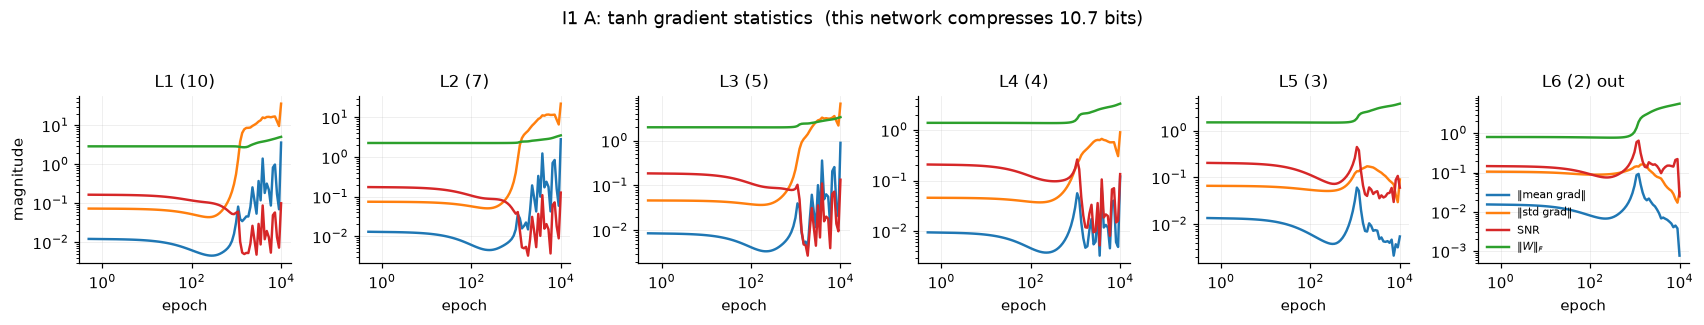

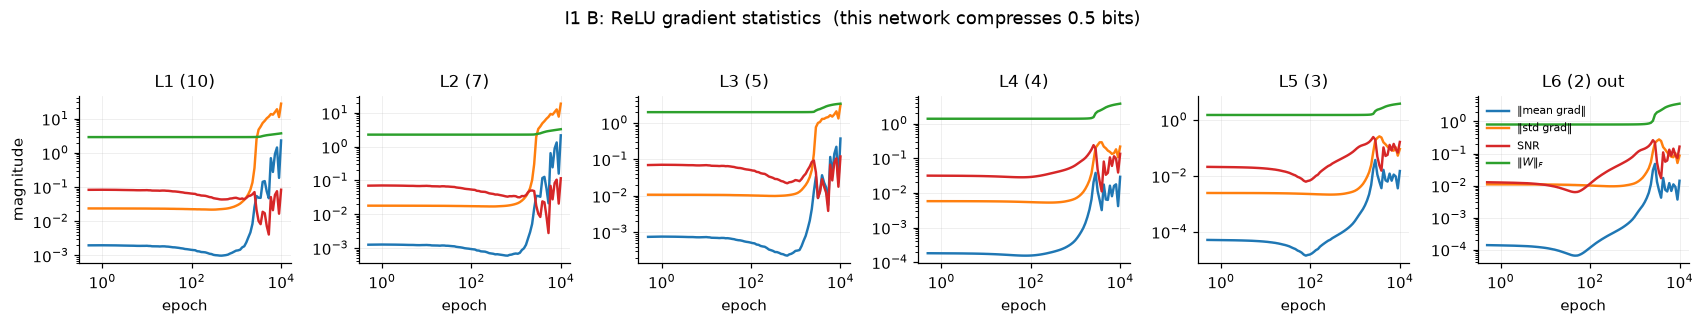

In [5]:
fig = plotting.gradient_snr_panel(
    logs[("tanh", "SGD")].epochs, logs[("tanh", "SGD")].grad_mean_norm,
    logs[("tanh", "SGD")].grad_std_norm, logs[("tanh", "SGD")].weight_norms,
    layer_names=logs[("tanh", "SGD")].layer_names,
    title="I1 A: tanh gradient statistics  (this network compresses 10.7 bits)")
plotting.save(fig, "figI1A_snr_tanh", FIGDIR)
plt.show()

fig = plotting.gradient_snr_panel(
    logs[("relu", "SGD")].epochs, logs[("relu", "SGD")].grad_mean_norm,
    logs[("relu", "SGD")].grad_std_norm, logs[("relu", "SGD")].weight_norms,
    layer_names=logs[("relu", "SGD")].layer_names,
    title="I1 B: ReLU gradient statistics  (this network compresses 0.5 bits)")
plotting.save(fig, "figI1B_snr_relu", FIGDIR)
plt.show()

In [6]:
print(f"{'network':8s} {'layer':10s} {'SNR max':>9s} {'SNR final':>10s} {'drop':>8s} "
      f"{'||W|| growth':>13s} {'compresses?':>12s}")
print("-" * 78)
for act in ["tanh", "relu"]:
    log, pl = logs[(act, "SGD")], planes[(act, "SGD")]
    for j, ln in enumerate(log.layer_names):
        snr = log.grad_snr[:, j]
        wg = log.weight_norms[-1, j] / log.weight_norms[0, j]
        comp = "yes" if pl.compression[j] > 0.5 else "no"
        print(f"{act:8s} {ln:10s} {np.nanmax(snr):>9.3f} {snr[-1]:>10.3f} "
              f"{np.nanmax(snr) / max(snr[-1], 1e-12):>7.0f}x {wg:>12.2f}x {comp:>12s}")
    print()

network  layer        SNR max  SNR final     drop  ||W|| growth  compresses?
------------------------------------------------------------------------------
tanh     L1 (10)        0.166      0.100       2x         1.75x           no
tanh     L2 (7)         0.175      0.127       1x         1.56x           no
tanh     L3 (5)         0.185      0.134       1x         1.68x           no
tanh     L4 (4)         0.260      0.134       2x         2.39x          yes
tanh     L5 (3)         0.448      0.060       7x         2.51x          yes
tanh     L6 (2) out     0.650      0.025      26x         7.08x          yes

relu     L1 (10)        0.084      0.084       1x         1.29x           no
relu     L2 (7)         0.116      0.116       1x         1.45x           no
relu     L3 (5)         0.120      0.120       1x         1.71x           no
relu     L4 (4)         0.238      0.134       2x         2.72x           no
relu     L5 (3)         0.244      0.163       1x         2.53x          

The two figures follow, panel for panel, **the same trajectory**: gradient norms flat while
the network sits near its small-weight initialisation, a sharp rise in both mean and
standard deviation as learning takes hold around epoch $10^3$, and a declining SNR
thereafter as the mean gradient collapses towards zero at the minimum.

The absolute SNR levels are not identical — tanh runs a little higher in most layers — but
nothing in the *shape* separates them. One of these networks compresses by 10.7 bits and the
other by 0.5, and you could not tell which from its gradient statistics. Whatever the SNR is
tracking, it is not compression.

Two honest caveats on our reproduction:

* Our SNR curves are **not** the clean monotone step of the paper's figure I1. They dip,
  spike at the onset of learning, then fall. With the learning rate needed to reach the
  paper's accuracy, the network is nearly static for the first $\sim10^3$ epochs, so the
  "drift" phase is compressed into a short window rather than spanning early training.
* The clean drift $\to$ diffusion step *does* appear in the minimal model below, which is
  where the argument is decisive anyway.

Note the green $\|W\|_F$ curves: weight norms grow in every layer of both networks. That is
appendix D's point — a tanh network *must* grow its weights to compute anything nonlinear,
and growing them is exactly what pushes it into saturation.

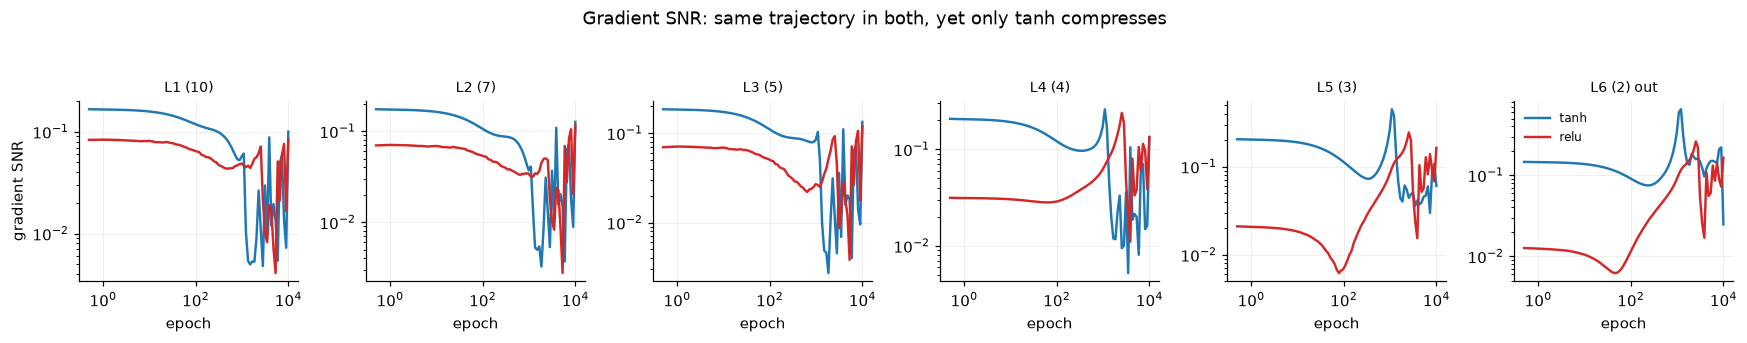

tanh : SNR range per layer [0.005 0.003 0.003 0.005 0.03  0.025] .. [0.166 0.175 0.185 0.26  0.448 0.65 ]
relu : SNR range per layer [0.004 0.003 0.004 0.011 0.006 0.006] .. [0.084 0.116 0.12  0.238 0.244 0.261]

layer         tanh SNR collapse   ReLU SNR collapse
---------------------------------------------------
L1 (10)                     35x                 20x
L2 (7)                      54x                 42x
L3 (5)                      68x                 31x
L4 (4)                      50x                 22x
L5 (3)                      15x                 39x
L6 (2) out                  26x                 42x

Both networks lose one to two orders of magnitude of gradient SNR over training.
The compressing and the non-compressing network are in the same regime.


In [7]:
# Overlay the two networks' SNR curves directly: if the gradient dynamics differ,
# it should show here.
fig, axes = plt.subplots(1, 6, figsize=(16.0, 2.9), sharex=True)
for j, ax in enumerate(axes):
    for act, c in [("tanh", "#1f77b4"), ("relu", "#d62728")]:
        lg = logs[(act, "SGD")]
        ax.plot(np.maximum(lg.epochs, 0.5), lg.grad_snr[:, j], color=c, label=act)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(logs[("tanh", "SGD")].layer_names[j], fontsize=9)
    ax.set_xlabel("epoch")
    if j == 0:
        ax.set_ylabel("gradient SNR")
axes[-1].legend(fontsize=8)
fig.suptitle("Gradient SNR: same trajectory in both, yet only tanh compresses", y=1.06)
fig.tight_layout()
plotting.save(fig, "figI1C_snr_overlay", FIGDIR)
plt.show()

for act in ["tanh", "relu"]:
    lg = logs[(act, "SGD")]
    print(f"{act:5s}: SNR range per layer "
          f"{np.round(np.nanmin(lg.grad_snr, axis=0), 3)} .. "
          f"{np.round(np.nanmax(lg.grad_snr, axis=0), 3)}")

# The levels differ slightly; the question is whether the *collapse* differs.
print()
print(f"{'layer':11s} {'tanh SNR collapse':>19s} {'ReLU SNR collapse':>19s}")
print("-" * 51)
for j, ln in enumerate(logs[("tanh", "SGD")].layer_names):
    ct = np.nanmax(logs[("tanh", "SGD")].grad_snr[:, j]) / np.nanmin(logs[("tanh", "SGD")].grad_snr[:, j])
    cr = np.nanmax(logs[("relu", "SGD")].grad_snr[:, j]) / np.nanmin(logs[("relu", "SGD")].grad_snr[:, j])
    print(f"{ln:11s} {ct:>18.0f}x {cr:>18.0f}x")
print()
print("Both networks lose one to two orders of magnitude of gradient SNR over training.")
print("The compressing and the non-compressing network are in the same regime.")

### Figure I2 — a minimal model where compression is impossible by construction

Take a linear network with a **single** hidden unit ($1$–$1$–$1$) and small initial
weights. With one hidden unit whose weight only grows, there is no room for $I(X;T)$ to
fall — compression is ruled out architecturally. If the SNR transition still appears, it is
conclusively independent of compression.

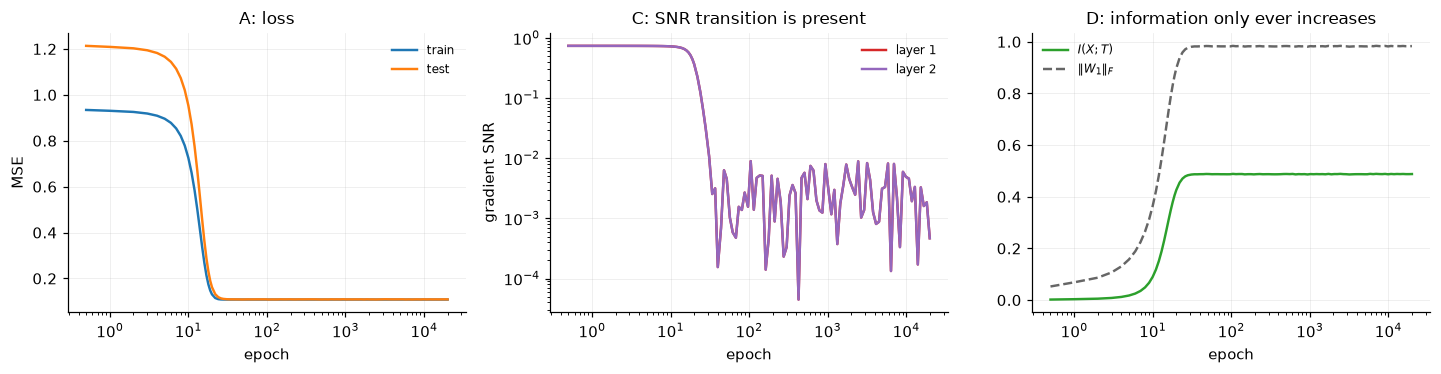

gradient SNR : 0.738 -> 4.47e-05  (16502x drop)
||W_1||_F    : 0.0527 -> 0.9832  (grows)
I(X;T)       : 0.0020 -> 0.4879  (compression: +0.00069 bits)


In [8]:
cfg_min = LinearConfig(hidden=(1,), n_inputs=1, n_train=100, snr=10.0, batch_size=1,
                       lr=0.001, n_epochs=20_000, init_std=0.05, seed=6)
res_min = cached(cfg_min.tag, lambda: run_linear(cfg_min), verbose=False)
Lm = res_min.log

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.5))
x = np.maximum(Lm.epochs, 0.5)

axes[0].plot(x, Lm.train_loss, label="train", color="#1f77b4")
axes[0].plot(x, Lm.test_loss, label="test", color="#ff7f0e")
axes[0].set_xscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_title("A: loss"); axes[0].legend()

axes[1].plot(x, Lm.grad_snr[:, 0], color="#d62728", label="layer 1")
axes[1].plot(x, Lm.grad_snr[:, 1], color="#9467bd", label="layer 2")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("gradient SNR")
axes[1].set_title("C: SNR transition is present"); axes[1].legend()

axes[2].plot(x, res_min.I_XT[:, 0], color="#2ca02c", label=r"$I(X;T)$")
axes[2].plot(x, Lm.weight_norms[:, 0], color="0.4", ls="--", label=r"$\|W_1\|_F$")
axes[2].set_xscale("log"); axes[2].set_xlabel("epoch")
axes[2].set_title("D: information only ever increases"); axes[2].legend()

fig.tight_layout()
plotting.save(fig, "figI2_minimal_snr", FIGDIR)
plt.show()

snr = Lm.grad_snr[:, 0]
print(f"gradient SNR : {np.nanmax(snr):.3f} -> {np.nanmin(snr):.2e}  "
      f"({np.nanmax(snr) / max(np.nanmin(snr), 1e-15):.0f}x drop)")
print(f"||W_1||_F    : {Lm.weight_norms[0, 0]:.4f} -> {Lm.weight_norms[-1, 0]:.4f}  (grows)")
print(f"I(X;T)       : {res_min.I_XT[0, 0]:.4f} -> {res_min.I_XT[-1, 0]:.4f}  "
      f"(compression: {res_min.I_XT[:, 0].max() - res_min.I_XT[-1, 0]:+.5f} bits)")

The intuition for why the transition is generic: weights start small, so early on *every*
sample agrees they should grow — a large, consistent mean gradient. Near the minimum the
mean gradient goes to zero **by definition of a minimum**, but the per-sample standard
deviation stays finite, because individual examples still disagree about which direction
would help them. So $m_l/s_l$ collapses at convergence in *any* setting. It is a property
of arriving at a minimum, described long before the IB literature as the transient/stochastic
or search/convergence phases (Murata 1998; Chee & Toulis 2017).

## 4.3 Figures 4C/4D — compression without generalisation

Notebook 3 showed networks that generalise *without* compressing. The dissociation's other
direction: a tanh network trained on only 30% of the data overfits noticeably, yet
compresses just as enthusiastically.

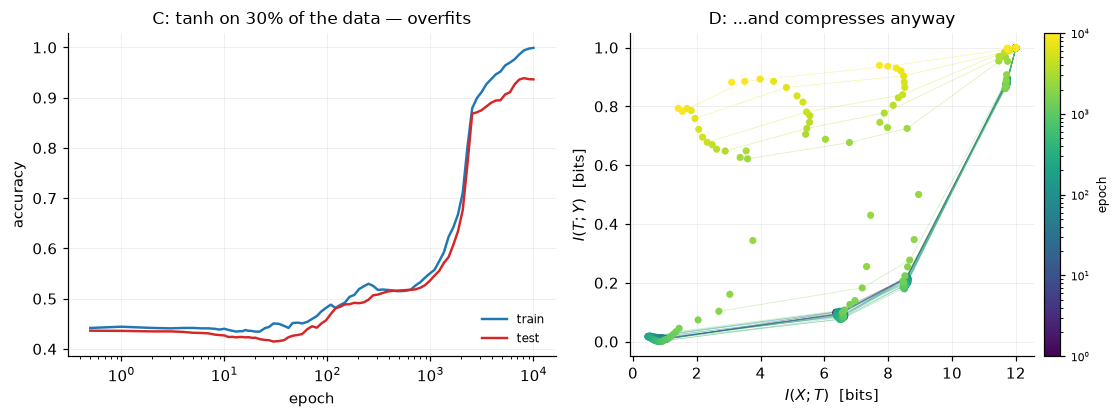

train acc 0.999  test acc 0.937  generalisation gap 0.063
total compression: 7.99 bits


In [9]:
cfg_of_tanh = TishbyConfig(activation="tanh", train_fraction=0.3, seed=0)
cfg_of_relu = TishbyConfig(activation="relu", train_fraction=0.3, seed=0)
log_of = cached(cfg_of_tanh.tag, lambda: run_tishby(cfg_of_tanh), verbose=False)
plane_of = tishby_plane(cfg_of_tanh, labels, estimator="binning")
plane_of_relu = tishby_plane(cfg_of_relu, labels, estimator="binning")

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.9))
ax = axes[0]
x = np.maximum(log_of.epochs, 0.5)
ax.plot(x, log_of.train_acc, label="train", color="#1f77b4")
ax.plot(x, log_of.test_acc, label="test", color="#d62728")
ax.set_xscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
ax.set_title("C: tanh on 30% of the data — overfits"); ax.legend(loc="lower right")

plotting.information_plane(plane_of.epochs, plane_of.I_XT, plane_of.I_TY, ax=axes[1],
                           title="D: ...and compresses anyway",
                           layer_names=plane_of.layer_names)
fig.tight_layout()
plotting.save(fig, "fig04CD_overfit_tanh", FIGDIR)
plt.show()

gap = log_of.train_acc[-1] - log_of.test_acc[-1]
print(f"train acc {log_of.train_acc[-1]:.3f}  test acc {log_of.test_acc[-1]:.3f}  "
      f"generalisation gap {gap:.3f}")
print(f"total compression: {plane_of.compression.sum():.2f} bits")

## 4.4 The full dissociation

Collecting every run in this project into one table. If compression caused generalisation,
the "compresses" and "generalises" columns would agree. All four combinations occur.

In [10]:
rows = [
    ("tanh, 80% data (fig 1A)",  planes[("tanh", "SGD")], logs[("tanh", "SGD")]),
    ("ReLU, 80% data (fig 1B)",  planes[("relu", "SGD")], logs[("relu", "SGD")]),
    ("tanh, 30% data (fig 4C)",  plane_of,                log_of),
    ("ReLU, 30% data",           plane_of_relu,
     cached(cfg_of_relu.tag, lambda: run_tishby(cfg_of_relu), verbose=False)),
]
print(f"{'network':26s} {'compression':>12s} {'compresses?':>12s} "
      f"{'gen. gap':>9s} {'generalises?':>13s}")
print("-" * 78)
for name, pl, log in rows:
    comp = pl.compression.sum()
    gap = log.train_acc[-1] - log.test_acc[-1]
    print(f"{name:26s} {comp:>9.2f} bits {'YES' if comp > 1 else 'no':>12s} "
          f"{gap:>9.3f} {'YES' if gap < 0.05 else 'no':>13s}")
print()
print("Compression and generalisation vary independently: all four combinations of")
print("(compresses, generalises) are realisable. Neither implies the other.")

network                     compression  compresses?  gen. gap  generalises?
------------------------------------------------------------------------------
tanh, 80% data (fig 1A)        10.66 bits          YES     0.019           YES
ReLU, 80% data (fig 1B)         0.47 bits           no     0.014           YES
tanh, 30% data (fig 4C)         7.99 bits          YES     0.063            no
ReLU, 30% data                  0.62 bits           no     0.055            no

Compression and generalisation vary independently: all four combinations of
(compresses, generalises) are realisable. Neither implies the other.


## Takeaways

1. Full-batch gradient descent has **no** stochasticity and therefore no diffusion, yet
   tanh networks compress just as much under it as under SGD — in fact *more* here
   (17.9 bits vs 10.7). The proposed mechanism is falsified by its own prediction.
2. The gradient-SNR dynamics of the compressing (tanh) and non-compressing (ReLU) networks
   are **indistinguishable**, and the textbook drift $\to$ diffusion step appears in a
   $1$–$1$–$1$ linear network where compression is impossible by construction. The SNR
   collapse is a property of converging to a minimum — the mean gradient vanishes there by
   definition while per-sample disagreement does not — and not of compressing a
   representation.
3. The theoretical step from "maximum-entropy distribution *over training runs*" to
   "maximises $H(X\mid T)$ *for one run*" conflates two distinct random variables.
4. All four combinations of (compresses, generalises) are realisable, so neither implies
   the other.

Next: [`05_simultaneous_fitting.ipynb`](05_simultaneous_fitting.ipynb) — the steelman. When
part of the input really is nuisance, does the network compress it away in a second phase?